# Testing (updated) simulations framework

## Imports

In [1]:
import pandas as pd
%load_ext autoreload
%autoreload 2

In [110]:
import matplotlib.pyplot as plt
from astropy.io import fits
import jax.numpy as jnp
import numpy as np
import cmasher as cmr
import jax
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0 = 70, Om0 = 0.3, Ode0 = 0.7)

#Progress bar (fancy)
from tqdm.notebook import tqdm as tqdm_notebook

In [4]:
import jax
import jax.numpy as jnp

In [5]:
from fast_turbulence_sim.grid import SpatialGrid3D
from fast_turbulence_sim.binning import LoadBinning
from fast_turbulence_sim.structure_function import StructureFunction
from fast_turbulence_sim.projection import Projection
from fast_turbulence_sim.simulation import Simulation

Define spatial grid

In [6]:
# Pixel size
pixsize_m = 317e-6 # 317 um
focal_length = 12 # 12 m
pixsize_arcmin = pixsize_m/focal_length * 180 / jnp.pi * 60
pixsize_kpc = pixsize_arcmin * cosmo.kpc_proper_per_arcmin(0.1).value

# Spatial grid
spatial_grid = SpatialGrid3D(pixsize=pixsize_kpc,
                             shape=(232,232),
                             los_factor=5)
print('The pixel size in kiloparsecs is {:.2f} kpc'.format(pixsize_kpc))

The pixel size in kiloparsecs is 10.05 kpc


Load the emissivity cube used for emission-weighting (see corresponding notebook for the creation of said cube)

In [7]:
# Emissivity cube
em = np.load('/Users/amolin/Documents/Code/DataOlympe/molin/data_newxifu/emissivity_cube_19p_newxifu_novign.npy')

Load the binning files and define SF

In [137]:
# Load binning
binning = LoadBinning(shape = (232,232),
                 binning_file = '/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/clusters/cluster_1_corr/cluster_1_repeat_1/3p_mosaic/region_dict.p',
                 count_map_file = '/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/clusters/cluster_1_corr/cluster_1_repeat_1/3p_mosaic/count_map.fits')

# Get values from binning
X_pixels, Y_pixels, bin_num_pix, nb_bins, xBar_bins, yBar_bins, bin_nb_map = binning()

# Load structure function
sf = StructureFunction(bins = jnp.geomspace(3,200,20))

Load the fits file defining the instrument PSF and to normalize it to one

In [138]:
PSF_kernel = jnp.array(fits.getdata('/Users/amolin/Documents/Code/DataOlympe/molin/data_newxifu/PSF_image.fits'), dtype = 'float64')
PSF_kernel *= 1/jnp.sum(PSF_kernel)
PSF_kernel_zero_padded = jnp.pad(PSF_kernel, pad_width = int((232-58)/2), mode = 'edge')

In [139]:
##Define the simulator
#Projection
projection = Projection(binning, em, PSF_kernel_zero_padded)

In [140]:
sim = Simulation(spatial_grid,
                 sf,
                 binning,
                 projection)

In [141]:
sigma = 116
log_inj = jnp.log10(300)
log_dis = jnp.log10(10)
alpha = 11/3

In [142]:
%time
@jax.jit
def run_sim(rng_key : jax.random.PRNGKey,
                 sigma : float,
                 log_inj : float,
                 log_dis : float,
                 alpha : float):

    return sim(rng_key,
               sigma,
                 log_inj ,
                 log_dis,
                 alpha )



CPU times: user 2 μs, sys: 1 μs, total: 3 μs
Wall time: 4.05 μs


In [143]:
%time
# --- Call ---
v_vec, std_vec = run_sim(jax.random.PRNGKey(61), sigma, log_inj, log_dis, alpha)

v_vec.block_until_ready()

CPU times: user 0 ns, sys: 1e+03 ns, total: 1e+03 ns
Wall time: 3.1 μs


Array([ 76.22066745,  69.10404145,   8.75894043,  36.37572616,
        -3.49669573, -16.81681423,  -8.94719644,  51.15586225,
       -20.86278065, -31.38490623, -30.3936702 ,   1.81480246,
         5.78310546,  37.32441322,  47.86498198,  38.49644322,
        58.53093297,  26.32670827, -28.78904307, -13.49046815,
         5.74037801,  11.92331838,  27.9996233 ,  15.77156605,
        19.22158351,  47.14704735,  25.22682999,  69.44885686,
        -6.69219949,  50.29429369,  52.96650419, -12.77715544,
        21.81549381,  22.95217938,  -1.29240723,  61.93656259,
        33.38302993,  -3.48744602, -11.46267502,  28.124274  ,
        19.78307171,  36.49834468,  17.94719359,   7.55870892,
        13.75523896, -14.87085147,  -6.58788898,   5.90616058,
        14.73442825, -28.75227733,   6.64100633, -15.94594608,
         9.31447759,   9.40076492, -21.34030463,   6.69080514,
         8.60012633,   5.59120571,  28.9081731 ,  -2.58732356,
        12.84910109,  -5.72556102,   6.26743461,  18.68

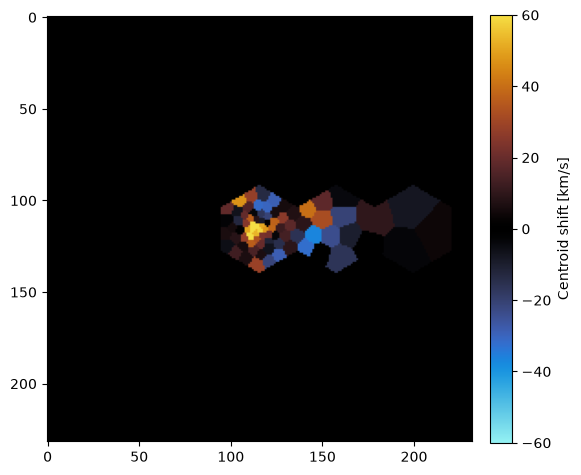

In [144]:
binned_censhift_output = jnp.zeros((232,232))
binned_censhift_output = binned_censhift_output.at[X_pixels, Y_pixels].set(v_vec[bin_num_pix])
fig,ax = plt.subplots(1,1, figsize = (6,6))

im =ax.imshow(binned_censhift_output, cmap = cmr.iceburn, vmin = -60, vmax = 60)
plt.colorbar(im, pad = 0.04, fraction = 0.046, label = 'Centroid shift [km/s]')

Look at the structure function

In [145]:
dist, sf_censhift = sf(v_vec, binning.xBar_bins,binning.yBar_bins)

In [146]:
dist, sf_broad = sf(std_vec, binning.xBar_bins,binning.yBar_bins)


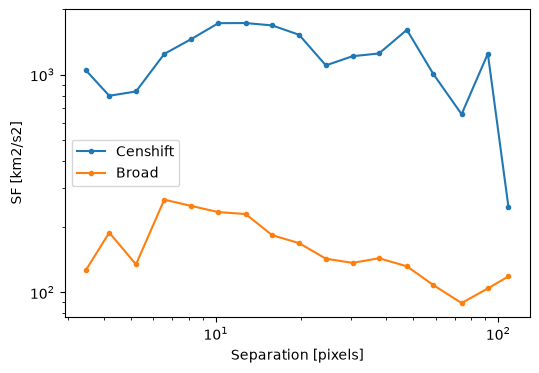

In [147]:
fig, ax = plt.subplots(1,1, figsize = (6,4))

ax.loglog(dist, sf_censhift, marker = '.', label = 'Censhift')
ax.loglog(dist, sf_broad, marker = '.', label = 'Broad')

ax.set_xlabel('Separation [pixels]')
ax.set_ylabel('SF [km2/s2]')
ax.legend()

Check that on average, the simulator outputs something around the observation used as a reference

In [148]:
Nsims = 100
vecs_censhift = np.zeros((Nsims,nb_bins))
vecs_broad = np.zeros((Nsims,nb_bins))

for k in tqdm_notebook(np.arange(Nsims), total = Nsims, desc=''):
    #Create key
    rng_key = jax.random.PRNGKey(np.random.randint(1e9))

    #Call function
    v_vec, std_vec = run_sim(rng_key,
                           sigma,
                           log_inj,
                           log_dis,
                           alpha)

    vecs_censhift[k] = v_vec
    vecs_broad[k] = std_vec

  0%|          | 0/100 [00:00<?, ?it/s]

Apply measurement error

In [149]:
from fast_turbulence_sim.apply_mes_error import MesError

In [150]:
path_model = '/Users/amolin/Documents/Code/DataOlympe/molin/data_newxifu/cluster_1_corrected/'

mes_error_censhift = MesError(path_model + "mdn_model_censhift.pt",
                              binning=binning
                              )

mes_error_broad = MesError(path_model + "mdn_model_broad.pt",
                              binning=binning
                              )

In [151]:
v_vec_pred = mes_error_censhift.apply(vec_input = vecs_censhift)


In [153]:
std_vec_pred = mes_error_broad.apply(vec_input = vecs_broad)


Obtain the structure function

In [154]:
@jax.jit
def apply_sf(vec):
    return sf(vec, binning.xBar_bins, binning.yBar_bins)


In [158]:
SFs_censhift = np.zeros((Nsims,19))
SFs_broad = np.zeros((Nsims,19))

for k in tqdm_notebook(np.arange(Nsims), total = Nsims, desc='Oui'):
    #Create key
    dist, sf_censhift = apply_sf(v_vec_pred[k])
    dist, sf_broad = apply_sf(std_vec_pred[k])

    SFs_censhift[k] = sf_censhift
    SFs_broad[k] = sf_broad

Oui:   0%|          | 0/100 [00:00<?, ?it/s]

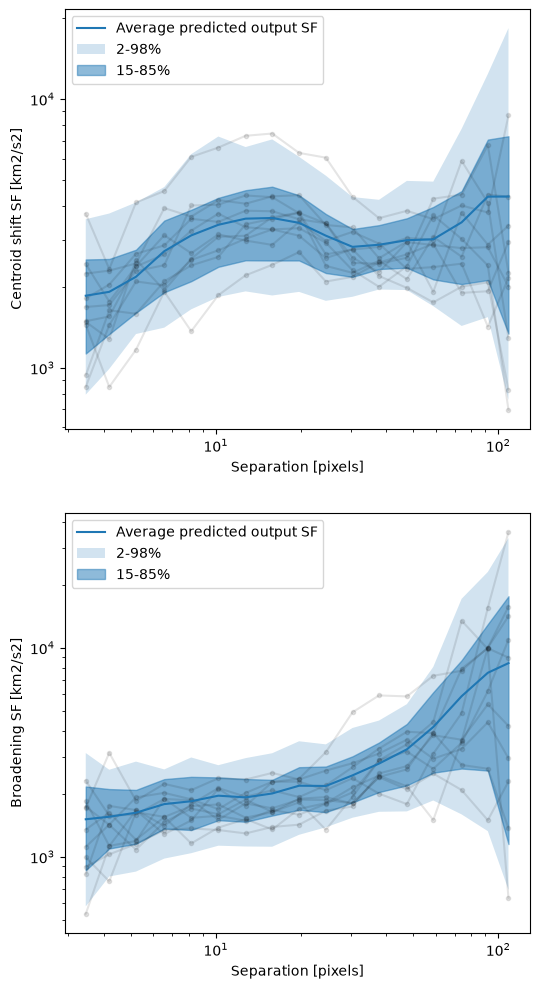

In [164]:
fig, ax = plt.subplots(2,1, figsize = (6,12))

for k in range(10):
    ax[0].loglog(dist[:17], sfs_censhift_10reps[k], marker ='.',c = 'k',
                     alpha = 0.1)
    ax[1].loglog(dist[:17], sfs_broad_10reps[k], marker ='.',c = 'k',
                     alpha = 0.1)

ax[0].loglog(dist, jnp.mean(SFs_censhift, axis =0),
            label = 'Average predicted output SF')

ax[0].fill_between(dist,
                   jnp.percentile(SFs_censhift, 2, axis = 0),
                   jnp.percentile(SFs_censhift, 98, axis = 0),
                   alpha = 0.2,
                   label = '2-98%'
                  )

ax[0].fill_between(dist,
                   jnp.percentile(SFs_censhift, 15, axis = 0),
                   jnp.percentile(SFs_censhift, 85, axis = 0),
                   alpha = 0.5,
                   color = 'tab:blue',
                   label = '15-85%')

ax[1].loglog(dist, jnp.mean(SFs_broad, axis =0),
            label = 'Average predicted output SF')

ax[1].fill_between(dist,
                   jnp.percentile(SFs_broad, 2, axis = 0),
                   jnp.percentile(SFs_broad, 98, axis = 0),
                   alpha = 0.2,
                   label = '2-98%')

ax[1].fill_between(dist,
                   jnp.percentile(SFs_broad, 15, axis = 0),
                   jnp.percentile(SFs_broad, 85, axis = 0),
                   alpha = 0.5,
                   color = 'tab:blue',
                   label = '15-85%')



ax[0].set_xlabel('Separation [pixels]')
ax[0].set_ylabel('Centroid shift SF [km2/s2]')
ax[0].legend()

ax[1].set_xlabel('Separation [pixels]')
ax[1].set_ylabel('Broadening SF [km2/s2]')
ax[1].legend()

In [162]:
data = np.load('/Users/amolin/Documents/Code/DataNUWA/XIFUHome/xifu_cluster_sim/clusters/cluster_1_corr/SFs_and_stats_cluster_1_10_reps_3p.npz')
sfs_censhift_10reps = data['sfs_censhift_10reps'][:,:17]
sfs_broad_10reps = data['sfs_broad_10reps'][:,:17]
means_censhift_10reps = data['means_censhift_10reps']
stds_censhift_10reps = data['stds_censhift_10reps']
means_broad_10reps = data['means_broad_10reps']
stds_broad_10reps = data['stds_broad_10reps']